Loading data from: c:\Users\Home-User\WK5-fraud-detection\data\processed\processed_fraud_data.csv
Applying SMOTE to training data...
Training Random Forest...
Training XGBoost...

--- Random Forest Results ---
AUC-PR Score: 0.6983
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     27393
           1       0.64      0.62      0.63      2830

    accuracy                           0.93     30223
   macro avg       0.80      0.79      0.80     30223
weighted avg       0.93      0.93      0.93     30223


--- XGBoost Results ---
AUC-PR Score: 0.6899
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     27393
           1       0.78      0.58      0.66      2830

    accuracy                           0.95     30223
   macro avg       0.87      0.78      0.82     30223
weighted avg       0.94      0.95      0.94     30223



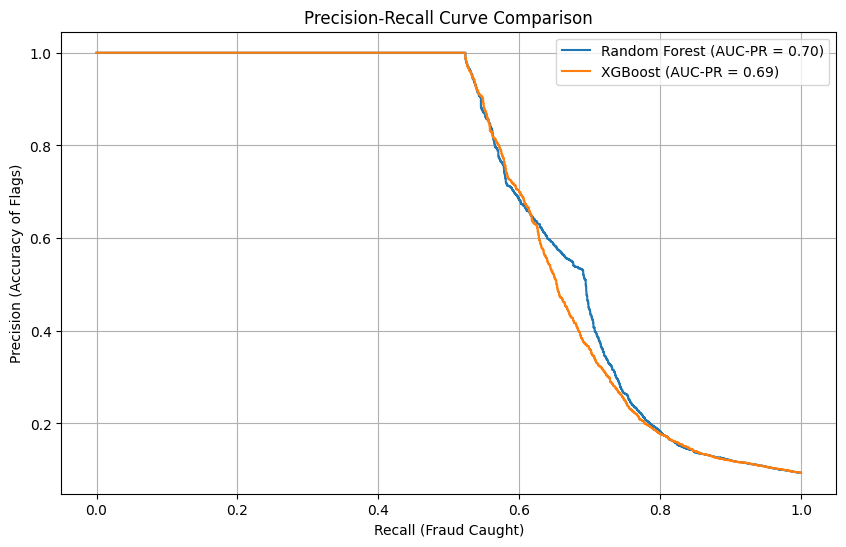

Winning model saved to: c:\Users\Home-User\WK5-fraud-detection\models\random_forest_fraud_model.pkl


In [5]:
import pandas as pd
import os
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, average_precision_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import joblib

# 1. FIX PATHS FOR JUPYTER
# This looks "up" one level from the 'notebooks' folder to find the 'data' folder
current_dir = os.getcwd()
data_path = os.path.join(current_dir, '..', 'data', 'processed', 'processed_fraud_data.csv')

print(f"Loading data from: {os.path.abspath(data_path)}")
df = pd.read_csv(data_path)

# 2. PREPARE DATA
# Drop non-numeric and ID columns
X = df.drop(columns=['class', 'user_id', 'device_id', 'signup_time', 'purchase_time'])
y = df['class']

# 3. TRAIN-TEST SPLIT (Before SMOTE)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 4. HANDLE IMBALANCE
print("Applying SMOTE to training data...")
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# 5. TRAIN MODELS
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)
rf_model.fit(X_train_res, y_train_res)

print("Training XGBoost...")
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
xgb_model.fit(X_train_res, y_train_res)

# 6. EVALUATION FUNCTION
def evaluate_model(model, X_test, y_test, name):
    probs = model.predict_proba(X_test)[:, 1]
    auc_pr = average_precision_score(y_test, probs)
    precision, recall, _ = precision_recall_curve(y_test, probs)
    
    print(f"\n--- {name} Results ---")
    print(f"AUC-PR Score: {auc_pr:.4f}")
    print(classification_report(y_test, model.predict(X_test)))
    
    return precision, recall, auc_pr

# Run Evaluations
pre_rf, rec_rf, auc_rf = evaluate_model(rf_model, X_test, y_test, "Random Forest")
pre_xgb, rec_xgb, auc_xgb = evaluate_model(xgb_model, X_test, y_test, "XGBoost")

# 7. VISUALIZE PRECISION-RECALL CURVE (Critical for your report)
plt.figure(figsize=(10, 6))
plt.plot(rec_rf, pre_rf, label=f'Random Forest (AUC-PR = {auc_rf:.2f})')
plt.plot(rec_xgb, pre_xgb, label=f'XGBoost (AUC-PR = {auc_xgb:.2f})')
plt.xlabel('Recall (Fraud Caught)')
plt.ylabel('Precision (Accuracy of Flags)')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

# 8. SAVE THE WINNER
model_save_path = os.path.join(current_dir, '..', 'models', 'random_forest_fraud_model.pkl')
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)
joblib.dump(rf_model, model_save_path)
print(f"Winning model saved to: {os.path.abspath(model_save_path)}")